In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('C:\\Users\\ACER\\Desktop\\Major-2\\data1\\Resume\\Resume.csv')

In [3]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [5]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [6]:
df.shape

(2484, 4)

In [10]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [12]:
df[df['Category']=='ENGINEERING']

,ID,Resume_str,Resume_html,Category
1690,14206561,ENGINEERING TECHNICIAN High...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1691,15139979,ENGINEERING ASSISTANT Summary ...,"<div class=""RNA skn-cnt4 fontsize fontface vma...",ENGINEERING
1692,44624796,ENGINEERING MANAGER Profile ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1693,54227873,ENGINEERING INTERN Profession...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1694,28005884,ENGINEERING TECHNICIAN Summar...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
...,...,...,...,...
1803,31694970,INDUSTRIAL ENGINEERING INTERN P...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1804,33685075,"MANAGER, QUALITY ENGINEERING ...","<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1805,77828437,MECHANICAL DESIGN ENGINEERING INTERN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING
1806,35172961,PROCESS ENGINEERING INTERN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING


In [27]:
#dropping irrelevant column
drop_cols=['Resume_html','ID']
df1=df.drop(drop_cols,axis=1)

In [28]:
#renaming column
df1.rename(columns={'Resume_str':'Features'},inplace=True)

In [29]:
df1.head()

,Features,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [30]:
df1.shape

(2484, 2)

EDA

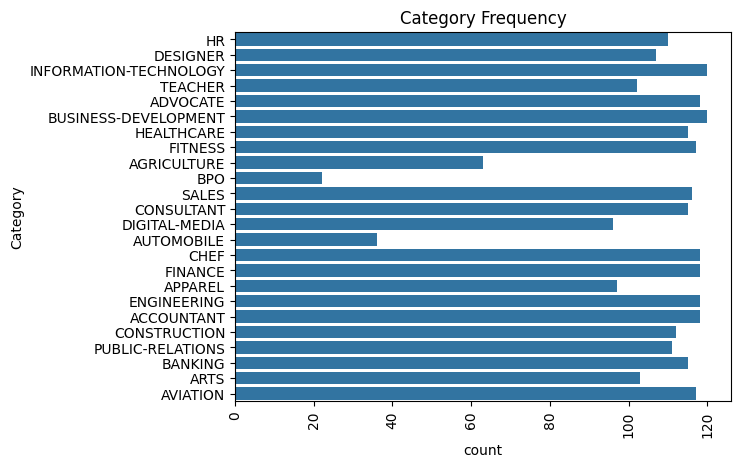

In [31]:
sns.countplot(df1['Category'])
plt.title('Category Frequency')
plt.xticks(rotation=90)
plt.show()
              

data imbalance few instances of category-> BPO,automobile,agriculture

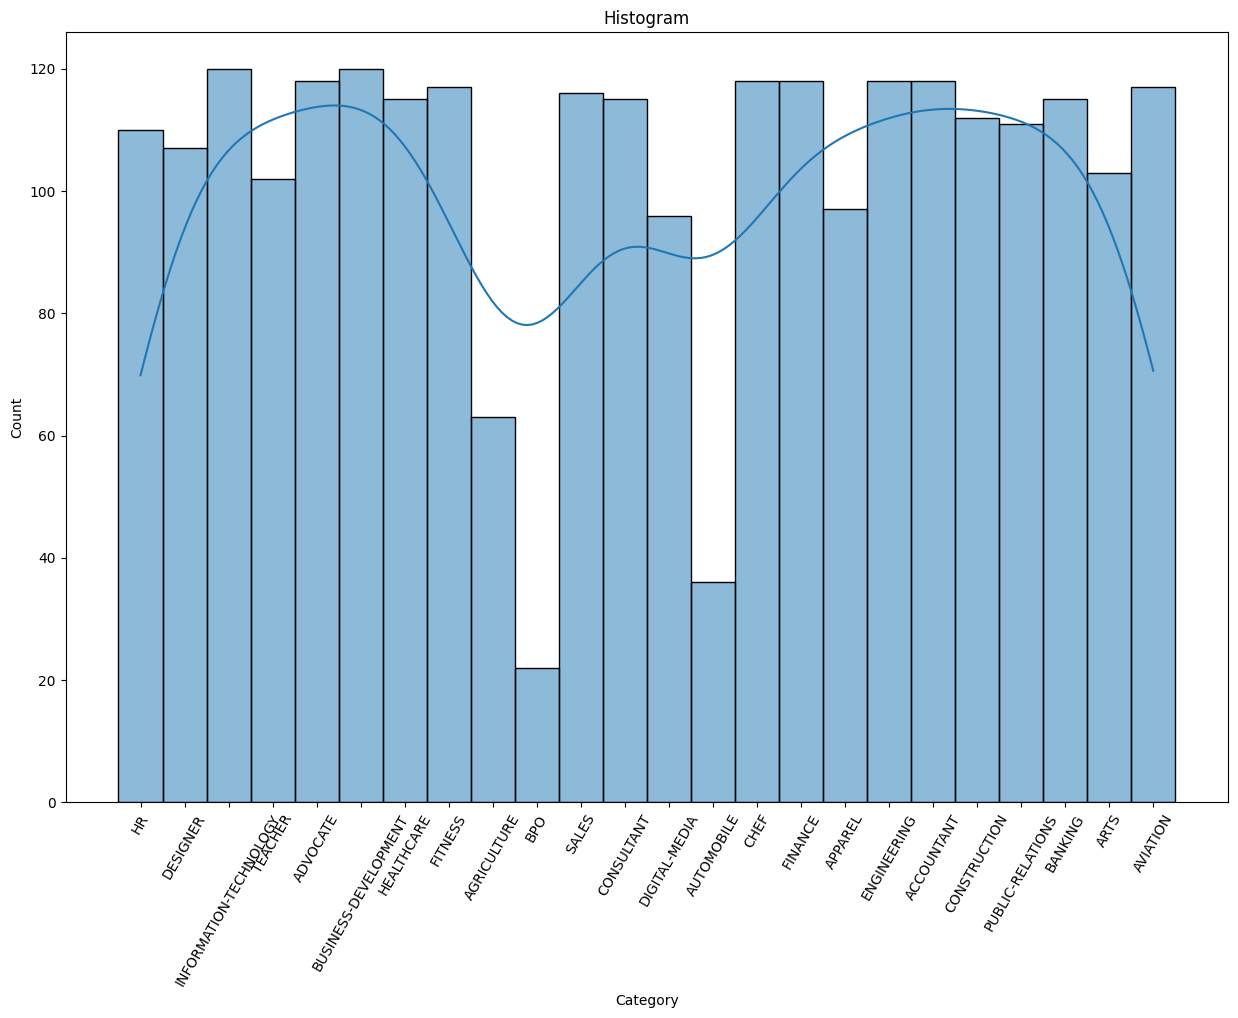

In [33]:
plt.figure(figsize=(15,10))
sns.histplot(x='Category',data=df1,kde=True)
plt.title('Histogram')
plt.xticks(rotation=60)
plt.show()
# not relevant doesn't give any real info for categorical data

Exploring Resume

In [42]:
df1['Category'][0]

'HR'

In [45]:
df1['Features']

0                HR ADMINISTRATOR/MARKETING ASSOCIATE\...
1                HR SPECIALIST, US HR OPERATIONS      ...
2                HR DIRECTOR       Summary      Over 2...
3                HR SPECIALIST       Summary    Dedica...
4                HR MANAGER         Skill Highlights  ...
                              ...                        
2479             RANK: SGT/E-5 NON- COMMISSIONED OFFIC...
2480             GOVERNMENT RELATIONS, COMMUNICATIONS ...
2481             GEEK SQUAD AGENT         Professional...
2482             PROGRAM DIRECTOR / OFFICE MANAGER    ...
2483             STOREKEEPER II       Professional Sum...
Name: Features, Length: 2484, dtype: object

In [46]:
df1['Features'][0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [47]:
df1['Features'][10]

'         HR ASSISTANT       Summary    Highly motivated, and a dynamic Human Resources professional with diverse credentials seeking a position with a growing organization to make a positive impact on company policies, and experience career growth. Accomplished human resources and administrative professional with over 3 years\' experience. Attentive to detail, able to take initiative, prioritize multiple tasks and manage workload. Resourceful team player with a can-do attitude. Results-driven with strong communication, analytical, and interpersonal skills while maintain the utmost confidentiality.      Highlights          Compensation knowledge  MS Office Suite  AR/AP proficiency  Oracle knowledge  Great communication skills  Great analytical skills\t*New Hire Training  Filing & Records   Management  Spreadsheets/Reports  Office Management  Customer Service  QuickBooks, Peachtree  New Hire paperwork                Experience     03/2016   to   Current     Company Name   －   City  ,   

### Preprocessing

In [49]:
df1['Category'] = df['Category'].str.title()

In [50]:
#cleaning feature column removing stop words,symbols other unneccesary stuffs

In [51]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [52]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ACER\AppData\Roaming\nltk_data...


True

In [53]:
stop_word=set(stopwords.words('english'))
lemma=WordNetLemmatizer()

In [60]:
#text cleaning function
def cleantxt(text):
    text=str(text).lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # remove URLs
    text = re.sub(r'\S+@\S+', '', text)  # remove email addresses
    text = re.sub(r'\d{1,2}[/-]\d{2,4}', '', text)  # remove dates 
    text = re.sub(r'\d{1,2}[/-]\d{2,4}', '', text) # remove all numbers
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation, commas, symbols 
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    
    text = ' '.join( # remove stopwords and apply lemmatization
        lemma.lemmatize(word)
        for word in text.split()
        if word not in stop_word
    )
    
    return text

df1['Features'] = df1['Features'].apply(cleantxt)




    

In [61]:
df1['Features'].head()

0    hr administratormarketing associate hr adminis...
1    hr specialist u hr operation summary versatile...
2    hr director summary year experience recruiting...
3    hr specialist summary dedicated driven dynamic...
4    hr manager skill highlight hr skill hr departm...
Name: Features, dtype: object

In [62]:
df1['Features'][0]

'hr administratormarketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customerfocused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction team management marketing savvy conflict resolution technique training development skilled multitasker client relation specialist accomplishment missouri dot supervisor training certification certified ihg customer loyalty marketing segment hilton worldwide general manager training certification accomplished trainer cross server hospitality system hilton onq micros opera pm fidelio opera reservation system or holidex completed course seminar customer service sale strategy inventory control loss prevention safety time management leadership performance assessment experience hr administratormarketing associate hr administrator dec current company name city state help develop policy directs c

In [63]:
df1['Features'][10]

'hr assistant summary highly motivated dynamic human resource professional diverse credential seeking position growing organization make positive impact company policy experience career growth accomplished human resource administrative professional year experience attentive detail able take initiative prioritize multiple task manage workload resourceful team player cando attitude resultsdriven strong communication analytical interpersonal skill maintain utmost confidentiality highlight compensation knowledge m office suite arap proficiency oracle knowledge great communication skill great analytical skill new hire training filing record management spreadsheetsreports office management customer service quickbooks peachtree new hire paperwork experience current company name city state sourced recruited call center department throughout company responsible finding right candidate matching temporary permanent job placement company maintaining computer system updating entering data brassring

In [64]:
df1['Category'].head()

0    Hr
1    Hr
2    Hr
3    Hr
4    Hr
Name: Category, dtype: object

In [65]:
df1.head()

,Features,Category
0,hr administratormarketing associate hr adminis...,Hr
1,hr specialist u hr operation summary versatile...,Hr
2,hr director summary year experience recruiting...,Hr
3,hr specialist summary dedicated driven dynamic...,Hr
4,hr manager skill highlight hr skill hr departm...,Hr


In [67]:
# Storing the Cleaned Preprocessed dataset in a parquet file

In [68]:
df1.to_parquet(
    "cleaned_dataset.parquet",
    engine="pyarrow",
    index=False)

print("cleaned_dataset.parquet saved successfully")

cleaned_dataset.parquet saved successfully
